# Definitions

## 1. Required Packages and particular definitions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import * # Quantum Toolbox in Python
from numpy import *
from pylab import *
#import pandas as pd #To import and read .csv files
import scipy.linalg as lnag
from scipy.linalg import sqrtm, expm
from matplotlib import ticker, cm
import matplotlib.ticker as ticker
import itertools
from itertools import permutations
import sys
import os # permite a criação de pastas e acesso ao sistema operacional pelo Python
import matplotlib.font_manager as font_manager

# DEFINING MATHEMATICAL TOOLS

def chop(expr, ChopTol=10**-6):
	return np.ma.masked_inside(expr, -ChopTol, ChopTol).filled(0)

def r(N_res,dim_res,dim_qu):
	Sp1 = [ ] #Arising
	for i in range(0,N_res):
		if N_res == 1: 
			Sp1.append(destroy(dim_res))
		if N_res > 1: 
			qeyeN = [qeye(dim_res) for j in range(0,N_res-1)]
			qeyeN.insert(i,destroy(dim_res))
			Sp1.append(tensor(tensor(qeyeN),qeye(dim_qu)) ) 
	return Sp1

def a(dim_res,dim_qu):
	return tensor([qeye(dim_res),qeye(dim_res),destroy(dim_qu)])


Normalization = 10**8
MHz = 2*np.pi*10**6/Normalization
GHz = 2*np.pi*10**9/Normalization

nanosec = 10**(-9)*Normalization
microsec = 10**(-6)*Normalization


def H_qubits(parameters_matrix,dim_qu,dim_res): #(parameters_matrix = [frequency, anharmonicity], dimension, Number of qubits)
	H = parameters_matrix[0]*((a(dim_res,dim_qu)).dag()*(a(dim_res,dim_qu)))
	if dim_qu > 2:
		H += parameters_matrix[1]*( (a(dim_res,dim_qu)).dag()*(a(dim_res,dim_qu)).dag() )*( (a(dim_res,dim_qu))*(a(dim_res,dim_qu)) )
	return H

def H_drive(N_res,amplitude,frequency,phase,dim_qu,dim_res,tlist,t_0,w):
	exp_list_r1 = [np.exp( -((tlist - t_0)**2)/w -1.j*(frequency[0]*tlist - phase[0])), np.exp( -((tlist - t_0)**2)/w + 1.j*(frequency[0]*tlist - phase[0]))]
	exp_list_r2 = [np.exp( -((tlist - t_0)**2)/w -1.j*(frequency[1]*tlist - phase[1])), np.exp( -((tlist - t_0)**2)/w + 1.j*(frequency[1]*tlist - phase[1]))]
	#exp_list = [np.sin( (frequency*tlist - phase)), np.sin( (frequency*tlist - phase))]
	H = [[ r(N_res,dim_res,dim_qu)[0].dag() ,amplitude[0]*exp_list_r1[0] ], [ r(N_res,dim_res,dim_qu)[0],amplitude[0]*exp_list_r1[1] ], [r(N_res,dim_res,dim_qu)[1].dag() ,amplitude[1]*exp_list_r2[0] ], [r(N_res,dim_res,dim_qu)[1],amplitude[1]*exp_list_r2[1] ] ]
	return H


def H_resonator(frequency,dim_qu,dim_res,N_res):
	H = frequency[0]*r(N_res,dim_res,dim_qu)[0].dag()*r(N_res,dim_res,dim_qu)[0] + frequency[1]*r(N_res,dim_res,dim_qu)[1].dag()*r(N_res,dim_res,dim_qu)[1]
	return H


def H_qubit_resonator(g1,g2,dim_qu,dim_res,N_res):
	H = g1*( r(N_res,dim_res,dim_qu)[0].dag()*a(dim_res,dim_qu) + r(N_res,dim_res,dim_qu)[0]*a(dim_res,dim_qu).dag() ) + g2*( r(N_res,dim_res,dim_qu)[1].dag()*a(dim_res,dim_qu) + r(N_res,dim_res,dim_qu)[1]*a(dim_res,dim_qu).dag() )
	return H

def H_resonator_resonator(grr,dim_qu,dim_res,N_res):
	H = grr*( r(N_res,dim_res,dim_qu)[0].dag()*r(N_res,dim_res,dim_qu)[1] +r(N_res,dim_res,dim_qu)[1].dag()*r(N_res,dim_res,dim_qu)[0] ) 
	return H

def Variance(rho,Operator):
	v = trace( (Operator*Operator)*rho ) - trace( Operator*rho )**2
	return np.real(v)

def Drive_shape(amplitude_driv,frequencies_driv,t_0,w,times):
	pumpShape = [np.real(np.abs(amplitude_driv[0]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[0]*times - phase_driv[0])))), 
			  np.real(np.abs(amplitude_driv[1]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[0]*times - phase_driv[0]))))] 
	# ReShape = [np.real( amplitude_driv[0]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[0]*times - phase_driv[0])) ), 
	# 		np.real(amplitude_driv[1]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[1]*times - phase_driv[1])))] 
	# ImShape = [np.imag( amplitude_driv[0]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[0]*times - phase_driv[0])) ), 
	# 		np.imag(amplitude_driv[1]*np.exp( -((times - t_0)**2)/w -1.j*(frequencies_driv[1]*times - phase_driv[1])))] 
	return pumpShape[0]


#Defining dimensions
D_qu = 4

N_res = 2
D_res = 5

In [2]:


import matplotlib.font_manager as font_manager
Legendfont = font_manager.FontProperties(math_fontfamily='cm', size=18)
figsize = (9, 10) #5:44
cols = 2
rows = 3
'''Defining parameters to create the graphs in a better style'''
lslist = ['-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1)),'-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1))]
markerlist = ["o", "s", "D", "p", "v", "^", "X", "<", ">", "H","o", "s", "D", "p", "v", "^", "X", "<", ">", "H"]
leglist = [ 'N = 2', 'Dyn-1', 'Dyn-2', 'N = 5', 'N = 6', 'N = 7']

AxisParameters = 'width=5, length=10, labelsize=30'
AxisMinorParameters = 'width=1.2, length=4'
#Lines
Labels_FontSize = 20
Box_width = 2
x_interval = 0.5
y_interval = 5.0
decimalFormart = '{x:.2f}'
#Style of the exp data points
DontShow = 0.0
DataPointSize = 9
skip = 8
#Error Bars style
e_line_width = 3
ending_size = 4
#colorList = plt.cm.jet(np.linspace(0,1,len(Power[0])))
ColorsMarkers_lines = [
    ["#08589e", "#478fd3"],  # Azul
    ["#91003f", "#c994c7"],  # Rosa/Roxo
    ["#006600", "#99FF99"],  # Verde
    ["#cc4c02", "#fe9929"],  # Laranja
    ["black", "#E0E0E0"],     # Preto/Cinza
    ["#a50f15", "#fb6a4a"],  # Vermelho
    ["#54278f", "#9e9ac8"],  # Roxo
    ["#0868ac", "#43a2ca"],  # Ciano
    ["#8c510a", "#d8b365"],  # Marrom
    ["#b8860b", "#ffd700"],  # Dourado
    ["#a50f15", "#fb6a4a"],  # Vermelho
    ["#54278f", "#9e9ac8"],  # Roxo
    ["#0868ac", "#43a2ca"],  # Ciano
    ["#8c510a", "#d8b365"],  # Marrom
    ["#b8860b", "#ffd700"]  # Dourado
]
colorList = ['#332288','#117733',  '#E66100',  '#44AA99', '#882255', '#88CCEE',  '#DDCC77', '#CC6677' , '#332288','#117733',  '#AA4499',  '#44AA99', '#882255', '#88CCEE',  '#DDCC77', '#CC6677']
markerSizes = [7,7,7,7]

DataPoints = ["ms=DataPointSize, linewidth=0,markevery=8"]

csfont = {'fontname':'Times New Roman'}

# Simulations

## 1. Resonators case (no collateral and parasitic coupling)

In [3]:
#atom parameters
qubit_parameters = np.array([ 5.0, 0.3 ])*GHz

#Resonator parameters
frequencies_res = np.array([ 3.0, 7.0 ])*GHz

#Resonator-atom parameters
g_1 = 80*MHz
g_2 = 80*MHz

#Drive parameters
amplitude_driv = np.array([ 100, 100 ])*MHz
Delta1 = frequencies_res[0] - qubit_parameters[0]
Delta2 = frequencies_res[1] - qubit_parameters[0]
eta1 = g_1/Delta1
eta2 = g_2/Delta2
qubit_shift = eta1*g_1 + eta2*g_2
frequencies_driv = [qubit_parameters[0] - qubit_shift, qubit_parameters[0] - qubit_shift]
Ω = amplitude_driv[0]*g_1/Delta1
#Time to flip the qubit at resonance
τ_gate = (np.pi/2)/(2*abs(Ω))


print(' ==== RELEVANT PARAMETERS ==== ')
print('Cavity1-qubit dispersive shift (MHz):', eta1*g_1/MHz)
print('Cavity2-qubit dispersive shift (MHz):', eta2*g_2/MHz)
print('Total qubit dispersive shift (MHz):', qubit_shift/MHz)
print('Required driving field frequency (GHz):', frequencies_driv[0]/GHz)
print('Effective drive amplitude for each resonator:', Ω/MHz)
print('Qubit flip time in case of off-resonant fields:', τ_gate/nanosec)

 ==== RELEVANT PARAMETERS ==== 
Cavity1-qubit dispersive shift (MHz): -3.199999999999999
Cavity2-qubit dispersive shift (MHz): 3.1999999999999997
Total qubit dispersive shift (MHz): 8.834874115176437e-16
Required driving field frequency (GHz): 5.0
Effective drive amplitude for each resonator: -3.9999999999999982
Qubit flip time in case of off-resonant fields: 31.250000000000018


In [4]:
#Solving dynamics
t_final_1 = 0.1*microsec
N_times = int(400*GHz)#
times = np.linspace(0,t_final_1,N_times)
t_0 = 0*microsec
w = 1e5*microsec #To make sure the pulse is aproximatelly constant during the evolution time

phase_driv = np.array([ 0.0, 0.0 ])*np.pi
Htimed = H_drive(N_res,amplitude_driv,frequencies_driv,phase_driv,D_qu,D_res,times,t_0,w) 
H_TI1 = H_resonator(frequencies_res,D_qu,D_res,N_res) +  H_qubits(qubit_parameters,D_qu,D_res) + H_qubit_resonator(g_1,g_2,D_qu,D_res,N_res)
H_system = [H_TI1, Htimed[0], Htimed[1], Htimed[2], Htimed[3]]#
n_steps = 10**6#6
OptList = Options(nsteps=n_steps,atol=10**-10)


Pe = tensor(qeye(D_res),qeye(D_res),(basis(D_qu,0)*basis(D_qu,0).dag()))
N_k = destroy(D_res).dag()*destroy(D_res)
N1 = tensor(N_k,qeye(D_res),qeye(D_qu))
N2 = tensor(qeye(D_res),N_k,qeye(D_qu))

rho_g = tensor(basis(D_res,0), basis(D_res,0), basis(D_qu,0))
rho_t = qutip.sesolve(H_system, rho_g, times, [Pe,N1,N2], options=OptList)

def moving_average(x, w0):
    return np.convolve(x, np.ones(w0)/ w0, mode='same') 

n1 = rho_t.expect[1]
n2 = rho_t.expect[2]

Pg_inphase = rho_t.expect[0]
Pg_inphase_c = moving_average(Pg_inphase, 20)
n1_inphase = moving_average(n1, 1000)
n2_inphase = moving_average(n2, 1000)
times_n = times[:len(n1)]



phase_driv = np.array([ 0.0, 1.0 ])*np.pi

Htimed = H_drive(N_res,amplitude_driv,frequencies_driv,phase_driv,D_qu,D_res,times,t_0,w) 
H_TI1 = H_resonator(frequencies_res,D_qu,D_res,N_res) +  H_qubits(qubit_parameters,D_qu,D_res) + H_qubit_resonator(g_1,g_2,D_qu,D_res,N_res)
H_system = [H_TI1, Htimed[0], Htimed[1], Htimed[2], Htimed[3]]#
n_steps = 10**6#6
OptList = Options(nsteps=n_steps,atol=10**-10)


Pe = tensor(qeye(D_res),qeye(D_res),(basis(D_qu,0)*basis(D_qu,0).dag()))
N_k = destroy(D_res).dag()*destroy(D_res)
N1 = tensor(N_k,qeye(D_res),qeye(D_qu))
N2 = tensor(qeye(D_res),N_k,qeye(D_qu))

rho_g = tensor(basis(D_res,0), basis(D_res,0), basis(D_qu,0))
rho_t = qutip.sesolve(H_system, rho_g, times, [Pe,N1,N2], options=OptList)

def moving_average(x, w):
    return np.convolve(x, np.ones(w)/ w, mode='same') 

n1 = rho_t.expect[1]
n2 = rho_t.expect[2]

Pg_outphase = rho_t.expect[0]
Pg_outphase_c = moving_average(Pg_outphase, 20)
n1_outphase = moving_average(n1, 1000)
n2_outphase = moving_average(n2, 1000)
times_n = times[:len(n1)]



/home/acsantos/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/acsantos/anaconda3/lib/python3.13/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [5]:
PulseDrive_shape_2 = Drive_shape(amplitude_driv,frequencies_driv,t_0,w,times)
print(τ_gate/nanosec)


31.250000000000018


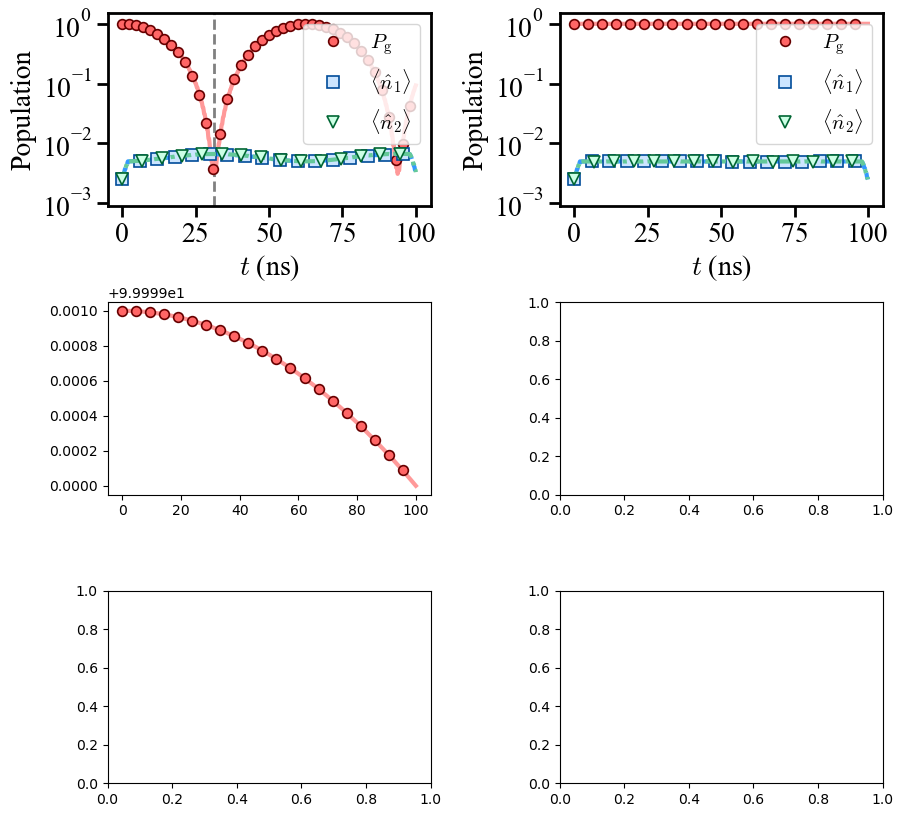

In [6]:
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
import matplotlib.ticker as ticker
from pylab import *

figsize = (10, 10)
cols = 2
rows = 3
fig, axs = plt.subplots(rows, cols, figsize=figsize)
fig.subplots_adjust(hspace=0.5,wspace=0.4)

lslist = ['-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1)),'-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1))]
markerlist = ['o', 's', 'v','o', 's', 'v','o', 's', 'v','o', 's', 'v','o', 's', 'v']
leglist = [ 'N = 2', 'Dyn-1', 'Dyn-2', 'N = 5', 'N = 6', 'N = 7']


AxisParameters = 'width=5, length=10, labelsize=30'
AxisMinorParameters = 'width=1.2, length=4'

#Lines
Labels_FontSize = 20
Box_width = 2
x_interval = 0.5
y_interval = 5.0
decimalFormart = '{x:.2f}'

#Style of the exp data points
DontShow = 0.0
DataPointSize = 9
skip = 8

#Error Bars style
e_line_width = 3
ending_size = 4


DataPoints = ["ms=DataPointSize, linewidth=0,markevery=8"]

markerSizes = [7,7,7,7,7,7,7]

csfont = {'fontname':'Times New Roman'}

colorList = [['#660000','#FF6666','#FF9999'],['#004C99','#CCE5FF','#3399FF'],['#006633','#CCFFE5','#64C99A']]
import matplotlib.font_manager as font_manager
Legendfont = font_manager.FontProperties(math_fontfamily='cm', size=15)

l1,l2 = 0,0
nc = 0
axs[l1][l2].axvline(τ_gate/nanosec, linewidth=2.0, color='grey', ls = '--')
axs[l1][l2].plot(times/nanosec, Pg_outphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_outphase, linewidth=0, label = r'$P_{\mathrm{g}}$', markersize = markerSizes[nc] , marker = markerlist[0], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 600)
nc = 1
axs[l1][l2].plot(times_n/nanosec, n1_outphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times_n/nanosec, n1_outphase , linewidth=0, label = r'$\langle \hat{n}_{1} \rangle$', markersize = markerSizes[nc]+1 , marker = markerlist[1], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1500)
nc = 2
axs[l1][l2].plot(times_n/nanosec, n2_outphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times_n/nanosec , n2_outphase, linewidth=0, label = r'$\langle \hat{n}_{2} \rangle$', markersize = markerSizes[nc]+1 , marker = markerlist[2], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1700)

l1,l2 = 0,1
nc = 0
axs[l1][l2].plot(times/nanosec, Pg_inphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_inphase, linewidth=0, label = r'$P_{\mathrm{g}}$', markersize = markerSizes[nc] , marker = markerlist[0], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1200)
nc = 1
axs[l1][l2].plot(times_n/nanosec, n1_inphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times_n/nanosec, n1_inphase , linewidth=0, label = r'$\langle \hat{n}_{1} \rangle$', markersize = markerSizes[nc]+1 , marker = markerlist[1], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1500)
nc = 2
axs[l1][l2].plot(times_n/nanosec, n2_inphase, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times_n/nanosec , n2_inphase, linewidth=0, label = r'$\langle \hat{n}_{2} \rangle$', markersize = markerSizes[nc]+1 , marker = markerlist[2], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1700)

l1,l2 = 1,0
nc = 0
axs[l1][l2].plot(times/nanosec, PulseDrive_shape_2/MHz, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, PulseDrive_shape_2/MHz, linewidth=0, label = r'$P_{\mathrm{g}}$', markersize = markerSizes[nc] , marker = markerlist[0], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1200)


for l1 in [0]:
    for l2 in [0,1]:
        for label in (axs[l1][l2].get_xticklabels() + axs[l1][l2].get_yticklabels()):
            label.set_fontname('Times New Roman')
        axs[l1][l2].legend(prop=Legendfont,loc='best')
        axs[l1][l2].set_ylabel(r"Population", fontsize = Labels_FontSize,math_fontfamily='cm', **csfont)
        axs[l1][l2].set_xlabel(r"$t$ (ns)", fontsize = Labels_FontSize, math_fontfamily='cm', **csfont)#, color = GrColor.GetColorLine('red',1)
        axs[l1][l2].xaxis.set_tick_params(width=Box_width, length=8, labelsize = Labels_FontSize)
        axs[l1][l2].yaxis.set_tick_params(width=Box_width, length=8, labelsize = Labels_FontSize)#, labelcolor= GrColor.GetColorLine('red',1)
        axs[l1][l2].tick_params(axis='y', which='minor', width = Box_width, length=4)
        axs[l1][l2].tick_params(axis='x', which='minor', width = Box_width, length=4)
        axs[l1][l2].set_ylim(0.0009, 1.5)
        axs[l1][l2].set_yscale('log')
        axs[l1][l2].yaxis.set_major_locator(LogLocator(base = 10, numticks = 15))
        axs[l1][l2].xaxis.set_major_locator(MultipleLocator(25))
        axs[l1][l2].xaxis.set_major_formatter('{x:.0f}')
        plt.setp(axs[l1][l2].spines.values(), linewidth=Box_width)

plt.savefig('No-EvanescentCoupling.pdf')

## 2. Resonators case (parasitic and collateral coupling - evanescent field analysis)

In [7]:
#atom parameters
qubit_parameters = np.array([ 5.0, 0.3 ])*GHz

#Resonator parameters
frequencies_res = np.array([ 3.0, 7.0 ])*GHz

#Resonator-atom parameters
g_1 = 80*MHz
g_2 = 80*MHz

#Drive parameters
amplitude_driv = np.array([ 100, 100 ])*MHz
Delta1 = frequencies_res[0] - qubit_parameters[0]
Delta2 = frequencies_res[1] - qubit_parameters[0]
eta1 = g_1/Delta1
eta2 = g_2/Delta2
qubit_shift = eta1*g_1 + eta2*g_2
frequencies_driv = [qubit_parameters[0] - qubit_shift, qubit_parameters[0] - qubit_shift]
Ω = amplitude_driv[0]*g_1/Delta1
#Time to flip the qubit at resonance
τ_gate = (np.pi/2)/(2*abs(Ω))



print(' ==== RELEVANT PARAMETERS ==== ')
print('Cavity1-qubit dispersive shift (MHz):', eta1*g_1/MHz)
print('Cavity2-qubit dispersive shift (MHz):', eta2*g_2/MHz)
print('Total qubit dispersive shift (MHz):', qubit_shift/MHz)
print('Required driving field frequency (GHz):', frequencies_driv[0]/GHz)
print('Effective drive amplitude for each resonator:', Ω/MHz)
print('Qubit flip time in case of off-resonant fields:', τ_gate/nanosec)

 ==== RELEVANT PARAMETERS ==== 
Cavity1-qubit dispersive shift (MHz): -3.199999999999999
Cavity2-qubit dispersive shift (MHz): 3.1999999999999997
Total qubit dispersive shift (MHz): 8.834874115176437e-16
Required driving field frequency (GHz): 5.0
Effective drive amplitude for each resonator: -3.9999999999999982
Qubit flip time in case of off-resonant fields: 31.250000000000018


In [8]:
g_list = np.linspace(0,10,200)

PG_outphase = []
PG_inphase = []

for g0 in g_list:
    g_collateral = g0*g_1

    #Solving dynamics
    t_final_1 = 0.5*microsec
    N_times = int(400*GHz)#
    times = np.linspace(0,t_final_1,N_times)
    t_0 = 0*microsec
    w = 1e5*microsec #To make sure the pulse is aproximatelly constant during the evolution time

    phase_driv = np.array([ 0.0, 0.0 ])*np.pi
    Htimed = H_drive(N_res,amplitude_driv,frequencies_driv,phase_driv,D_qu,D_res,times,t_0,w) 
    # Including resonator - resonator coupling directly
    H_TI1 = H_resonator(frequencies_res,D_qu,D_res,N_res) +  H_qubits(qubit_parameters,D_qu,D_res) + H_qubit_resonator(g_1,g_2,D_qu,D_res,N_res) + H_resonator_resonator(g_collateral,D_qu,D_res,N_res)
    H_system = [H_TI1, Htimed[0], Htimed[1], Htimed[2], Htimed[3]]#
    n_steps = 10**6#6
    OptList = Options(nsteps=n_steps,atol=10**-10)


    Pe = tensor(qeye(D_res),qeye(D_res),(basis(D_qu,0)*basis(D_qu,0).dag()))
    N_k = destroy(D_res).dag()*destroy(D_res)
    N1 = tensor(N_k,qeye(D_res),qeye(D_qu))
    N2 = tensor(qeye(D_res),N_k,qeye(D_qu))

    rho_g = tensor(basis(D_res,0), basis(D_res,0), basis(D_qu,0))
    rho_t = qutip.sesolve(H_system, rho_g, times, [Pe,N1,N2], options=OptList)

    def moving_average(x, w0):
        return np.convolve(x, np.ones(w0)/ w0, mode='same') 

    Pg_inphase = rho_t.expect[0]
    
    PG_inphase.append(Pg_inphase)







    phase_driv = np.array([ 0.0, 1.0 ])*np.pi

    Htimed = H_drive(N_res,amplitude_driv,frequencies_driv,phase_driv,D_qu,D_res,times,t_0,w) 
    H_TI1 = H_resonator(frequencies_res,D_qu,D_res,N_res) +  H_qubits(qubit_parameters,D_qu,D_res) + H_qubit_resonator(g_1,g_2,D_qu,D_res,N_res) + H_resonator_resonator(g_collateral,D_qu,D_res,N_res)
    H_system = [H_TI1, Htimed[0], Htimed[1], Htimed[2], Htimed[3]]#
    n_steps = 10**6#6
    OptList = Options(nsteps=n_steps,atol=10**-10)


    Pe = tensor(qeye(D_res),qeye(D_res),(basis(D_qu,0)*basis(D_qu,0).dag()))
    N_k = destroy(D_res).dag()*destroy(D_res)
    N1 = tensor(N_k,qeye(D_res),qeye(D_qu))
    N2 = tensor(qeye(D_res),N_k,qeye(D_qu))

    rho_g = tensor(basis(D_res,0), basis(D_res,0), basis(D_qu,0))
    rho_t = qutip.sesolve(H_system, rho_g, times, [Pe,N1,N2], options=OptList)

    def moving_average(x, w):
        return np.convolve(x, np.ones(w)/ w, mode='same') 

    #n1 = rho_t.expect[1]
    #n2 = rho_t.expect[2]

    Pg_outphase = rho_t.expect[0]

    PG_outphase.append(Pg_outphase)
#Pg_outphase_c = moving_average(Pg_outphase, 20)
#n1_outphase = moving_average(n1, 1000)
#n2_outphase = moving_average(n2, 1000)
#times_n = times[:len(n1)]



/home/acsantos/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/acsantos/anaconda3/lib/python3.13/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


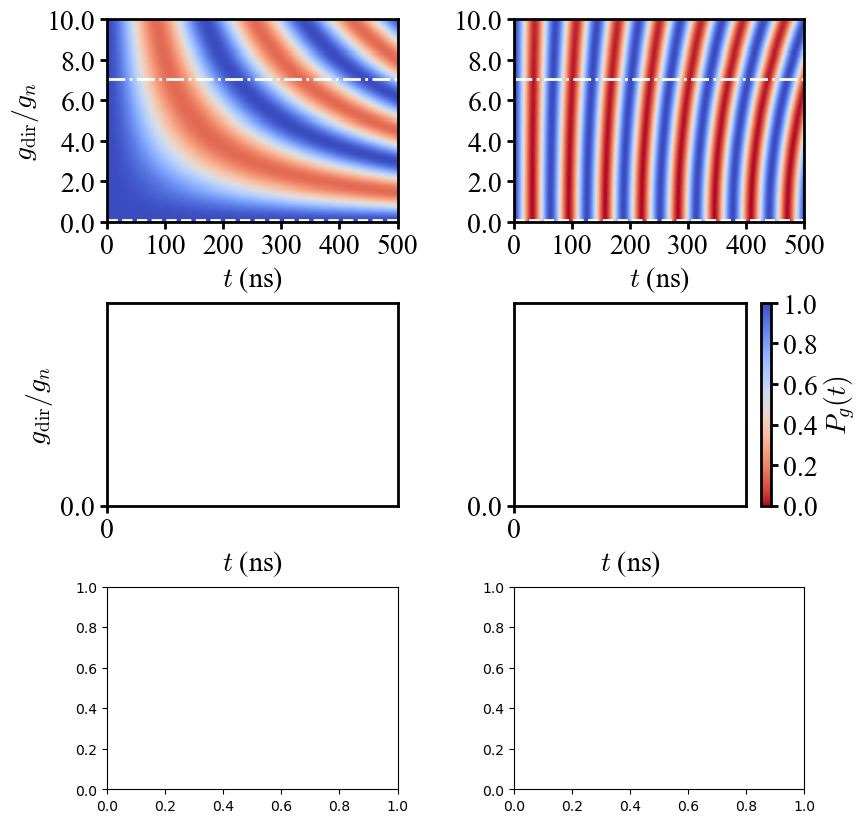

In [9]:
figsize = (9, 10) #5:44
cols = 2
rows = 3
fig, axs = plt.subplots(rows, cols, figsize=figsize)
fig.subplots_adjust(hspace=0.4,wspace=0.4)

import matplotlib.font_manager as font_manager
Legendfont = font_manager.FontProperties(math_fontfamily='cm', size=17)

#colorList = plt.cm.jet(np.linspace(0,1,len(Power[0])))
colorList = ['#332288','#117733',  '#E66100',  '#44AA99', '#882255', '#88CCEE',  '#DDCC77', '#CC6677' 
            , '#332288','#117733',  '#AA4499',  '#44AA99', '#882255', '#88CCEE',  '#DDCC77', '#CC6677']
markerSizes = np.ones(8)*7


l1,l2 = 0,0
axs[l1][l2].axhline(g_list[2], linewidth=2.0, color='white', ls = '--')
axs[l1][l2].axhline(g_list[140], linewidth=2.0, color='white', ls = '-.')
pcm = axs[l1][l2].imshow(PG_inphase, cmap='coolwarm_r', vmin=0, vmax=1.0, origin='lower', aspect='auto', extent=[(times/nanosec).min(), (times/nanosec).max(), g_list.min(), g_list.max()], interpolation='none')

l1,l2 = 0,1
axs[l1][l2].axhline(g_list[2], linewidth=2.0, color='white', ls = '--')
axs[l1][l2].axhline(g_list[140], linewidth=2.0, color='white', ls = '-.')
axs[l1][l2].imshow(PG_outphase, cmap='coolwarm_r', vmin=0, vmax=1.0, origin='lower', aspect='auto', extent=[(times/nanosec).min(), (times/nanosec).max(), g_list.min(), g_list.max()], interpolation='none')

#y_space = abs( ω_scan[0]/(2*np.pi*GHz) - ω_scan[-1]/(2*np.pi*GHz))/5
for l1 in [0,1]:
    for l2 in [0,1]:
        for label in (axs[l1][l2].get_xticklabels() + axs[l1][l2].get_yticklabels()):
            label.set_fontname('Times New Roman')
        #axs[l1][l2].legend(prop=Legendfont,loc='best')
        axs[l1][l2].xaxis.set_tick_params(width=Box_width, length=5, labelsize = Labels_FontSize)
        axs[l1][l2].yaxis.set_tick_params(width=Box_width, length=5, labelsize = Labels_FontSize)#, labelcolor= GrColor.GetColorLine('red',1)
        axs[l1][l2].tick_params(axis='y', which='minor', width = Box_width, length=4)
        axs[l1][l2].tick_params(axis='x', which='minor', width = Box_width, length=4)
        axs[l1][l2].set_xlabel(r"$t$ (ns)", fontsize = Labels_FontSize,math_fontfamily='cm', **csfont)
        if (l1,l2) in [(0,0)]:
            axs[l1][l2].set_ylabel(r"$g_{\mathrm{dir}} / g_{n}$", fontsize = Labels_FontSize,math_fontfamily='cm', **csfont)
        if (l1,l2) in [(1,0)]:
            axs[l1][l2].set_ylabel(r"$g_{\mathrm{dir}} / g_{n}$", fontsize = Labels_FontSize,math_fontfamily='cm', **csfont)
        axs[l1][l2].xaxis.set_major_formatter('{x:.0f}')
        #axs[l1][l2].set_xlim( 0, 0.5)
        #axs[l1][l2].set_ylim( 0, 1.0)
        axs[l1][l2].yaxis.set_major_formatter('{x:.1f}')
        axs[l1][l2].xaxis.set_major_locator(MultipleLocator(100))
        axs[l1][l2].yaxis.set_major_locator(MultipleLocator(2))
        if (l1,l2) in [(1,1)]:
            cbar = fig.colorbar(pcm, ax=axs[l1][l2])
        plt.setp(axs[l1][l2].spines.values(), linewidth=Box_width)

# Match font settings with main axes
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(Labels_FontSize)

cbar.ax.yaxis.set_tick_params(width=Box_width, length=5)
plt.setp(cbar.ax.spines.values(), linewidth=Box_width)

# If you also want the colorbar label font to match:
cbar.set_label(r"$P_{g}(t)$",
               fontsize=Labels_FontSize, 
               math_fontfamily='cm',
               **csfont)

plt.savefig('PlotMap_parasitic.pdf')

In [10]:
print(g_list[2])

print(g_list[140])

0.10050251256281408
7.035175879396985


In [11]:
Pg_outphase_05 = PG_outphase[2]
Pg_inphase_05 = PG_inphase[2]

Pg_outphase_7 = PG_outphase[140]
Pg_inphase_7 = PG_inphase[140]

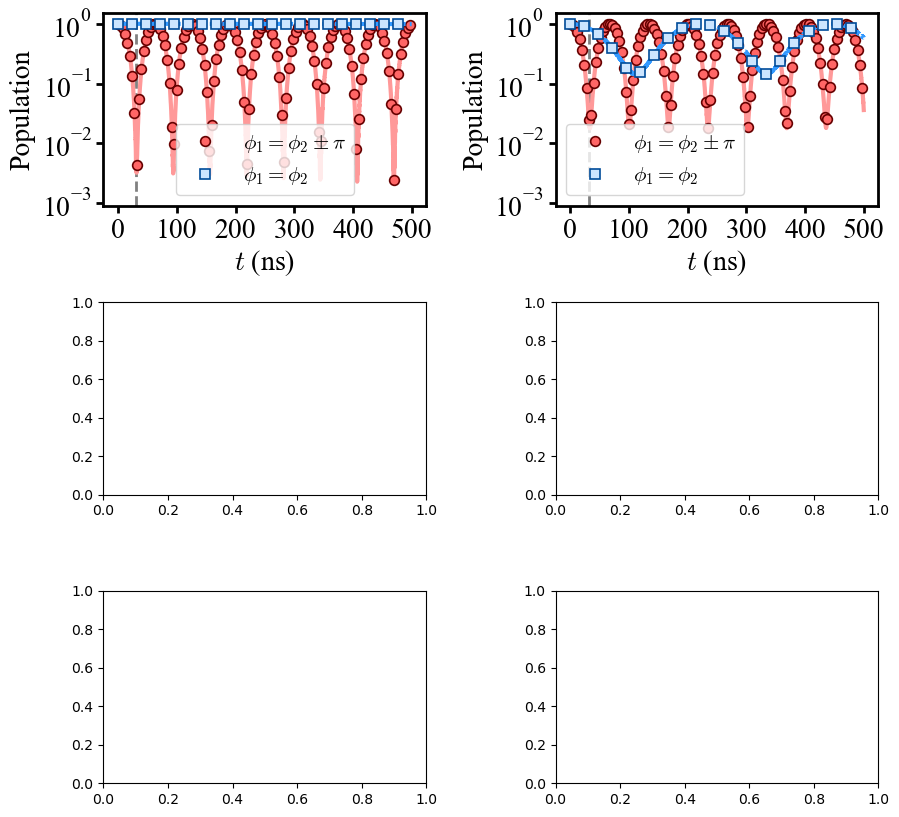

In [12]:
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
import matplotlib.ticker as ticker
from pylab import *

figsize = (10, 10)
cols = 2
rows = 3
fig, axs = plt.subplots(rows, cols, figsize=figsize)
fig.subplots_adjust(hspace=0.5,wspace=0.4)

lslist = ['-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1)),'-', (2, (2, 1)), (1, (3, 1, 1, 1)), (0, (3, 1)), (0, (1, 1))]
markerlist = ['o', 's', 'v','o', 's', 'v','o', 's', 'v','o', 's', 'v','o', 's', 'v']
leglist = [ 'N = 2', 'Dyn-1', 'Dyn-2', 'N = 5', 'N = 6', 'N = 7']


AxisParameters = 'width=5, length=10, labelsize=30'
AxisMinorParameters = 'width=1.2, length=4'

#Lines
Labels_FontSize = 20
Box_width = 2
x_interval = 0.5
y_interval = 5.0
decimalFormart = '{x:.2f}'

#Style of the exp data points
DontShow = 0.0
DataPointSize = 9
skip = 8

#Error Bars style
e_line_width = 3
ending_size = 4


DataPoints = ["ms=DataPointSize, linewidth=0,markevery=8"]

markerSizes = [7,7,7,7,7,7,7]

csfont = {'fontname':'Times New Roman'}

colorList = [['#660000','#FF6666','#FF9999'],['#004C99','#CCE5FF','#3399FF'],['#006633','#CCFFE5','#64C99A']]
import matplotlib.font_manager as font_manager
Legendfont = font_manager.FontProperties(math_fontfamily='cm', size=15)

l1,l2 = 0,0
nc = 0
axs[l1][l2].axvline(τ_gate/nanosec, linewidth=2.0, color='grey', ls = '--')
axs[l1][l2].plot(times/nanosec, Pg_outphase_05, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_outphase_05, linewidth=0, label = r'$\phi_{1}=\phi_{2}\pm\pi$', markersize = markerSizes[nc] , marker = markerlist[0], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 200)

nc = 1
axs[l1][l2].plot(times/nanosec, Pg_inphase_05, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_inphase_05, linewidth=0, label = r'$\phi_{1}=\phi_{2}$', markersize = markerSizes[nc] , marker = markerlist[1], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1200)


l1,l2 = 0,1
nc = 0
axs[l1][l2].axvline(τ_gate/nanosec, linewidth=2.0, color='grey', ls = '--')
axs[l1][l2].plot(times/nanosec, Pg_outphase_7, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_outphase_7, linewidth=0, label = r'$\phi_{1}=\phi_{2}\pm\pi$', markersize = markerSizes[nc] , marker = markerlist[0], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 200)

nc = 1
axs[l1][l2].plot(times/nanosec, Pg_inphase_7, linewidth=3, ls = lslist[nc], color = colorList[nc][2])
axs[l1][l2].plot(times/nanosec, Pg_inphase_7, linewidth=0, label = r'$\phi_{1}=\phi_{2}$', markersize = markerSizes[nc] , marker = markerlist[1], mec=colorList[nc][0]
                , mfc=colorList[nc][1], markeredgewidth=1.2, markevery = 1200)

for l1 in [0]:
    for l2 in [0,1]:
        for label in (axs[l1][l2].get_xticklabels() + axs[l1][l2].get_yticklabels()):
            label.set_fontname('Times New Roman')
        axs[l1][l2].legend(prop=Legendfont,loc='best')
        axs[l1][l2].set_ylabel(r"Population", fontsize = Labels_FontSize,math_fontfamily='cm', **csfont)
        axs[l1][l2].set_xlabel(r"$t$ (ns)", fontsize = Labels_FontSize, math_fontfamily='cm', **csfont)#, color = GrColor.GetColorLine('red',1)
        axs[l1][l2].xaxis.set_tick_params(width=Box_width, length=5, labelsize = Labels_FontSize)
        axs[l1][l2].yaxis.set_tick_params(width=Box_width, length=5, labelsize = Labels_FontSize)#, labelcolor= GrColor.GetColorLine('red',1)
        axs[l1][l2].tick_params(axis='y', which='minor', width = Box_width, length=4)
        axs[l1][l2].tick_params(axis='x', which='minor', width = Box_width, length=4)
        axs[l1][l2].set_ylim(0.0009, 1.5)
        axs[l1][l2].set_yscale('log')
        axs[l1][l2].yaxis.set_major_locator(LogLocator(base = 10, numticks = 15))
        axs[l1][l2].xaxis.set_major_locator(MultipleLocator(100))
        axs[l1][l2].xaxis.set_major_formatter('{x:.0f}')
        plt.setp(axs[l1][l2].spines.values(), linewidth=Box_width)

plt.savefig('With-EvanescentCoupling.pdf')